## Metrics and Evaluation - Heart Disease Prediction Dataset

In this notebook, the user will develop a classification model designed to predict the presence of heart disease in patients based on clinical parameters. The primary objective is to evaluate the model’s performance using a variety of classification metrics and validation techniques to ensure diagnostic reliability.

The dataset is sourced from [Kaggle](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset) and contains several medical predictor variables, such as age, cholesterol levels, and maximum heart rate achieved.

### Project Workflow

* **Data Acquisition:** Download and preprocess the `heartdisease.csv` dataset.
* **Model Training:** Implement a supervised learning algorithm to classify patients as either "Positive" or "Negative" for heart disease.
* **Performance Analysis:** Assess accuracy, precision, recall, and F1-score.
* **Export:** Upon successful evaluation, the final model will be exported into a format compatible with a **Node.js** environment for production-ready deployment.

In [4]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer, FunctionTransformer
from sklearn.compose import ColumnTransformer

In [5]:
# The `path` variable points to the directory of the downloaded files.
# We are interested in the `bank.csv` file specifically.
filepath = "heart.csv"

data = pd.read_csv(filepath)

data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## EDA

Let's start by exploring the dataset and understanding the features and target variable.
Here is the list of all features in the dataset:

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


### Target variable analysis

Our target variable is `heartDiseasse`, which indicates whether they are sick or not.

Text(0.5, 1.0, "Distribution of target variable 'HeartDisease'")

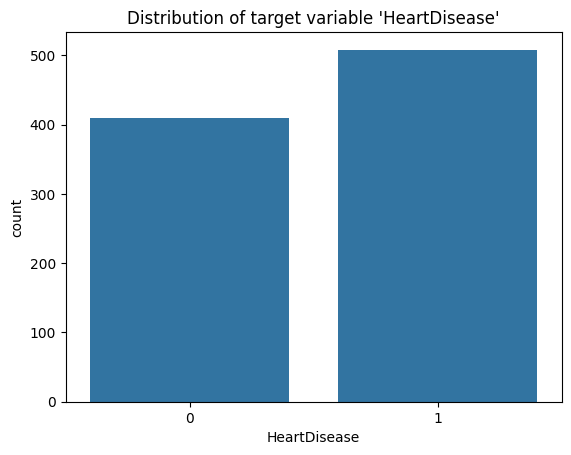

In [7]:
sns.countplot(data=data, x="HeartDisease")
plt.title("Distribution of target variable 'HeartDisease'")

### Feature analysis

Let's start by understanding the descriptive statistics of the dataset.

In [8]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


We can also visualize the distribution of numerical features.

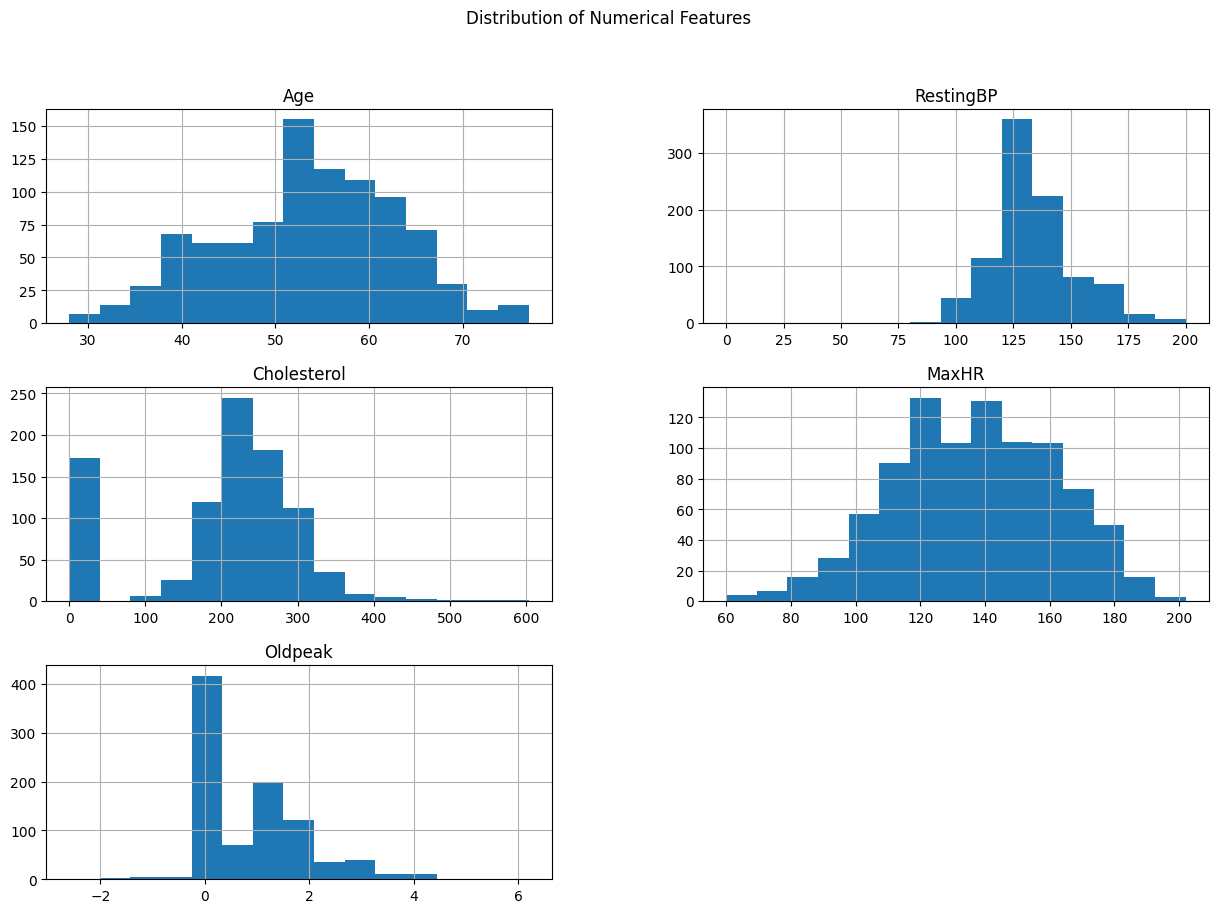

In [9]:
numerical_features = [    'Age',
    'RestingBP',
    'Cholesterol',
    'MaxHR',
    'Oldpeak']

data[numerical_features].hist(bins=15, figsize=(15, 10))
plt.suptitle("Distribution of Numerical Features")
plt.show()

Let's also look at the distribution of categorical features. Note that we are considering day and month as categorical features for this analysis, since they have a limited number of unique values.

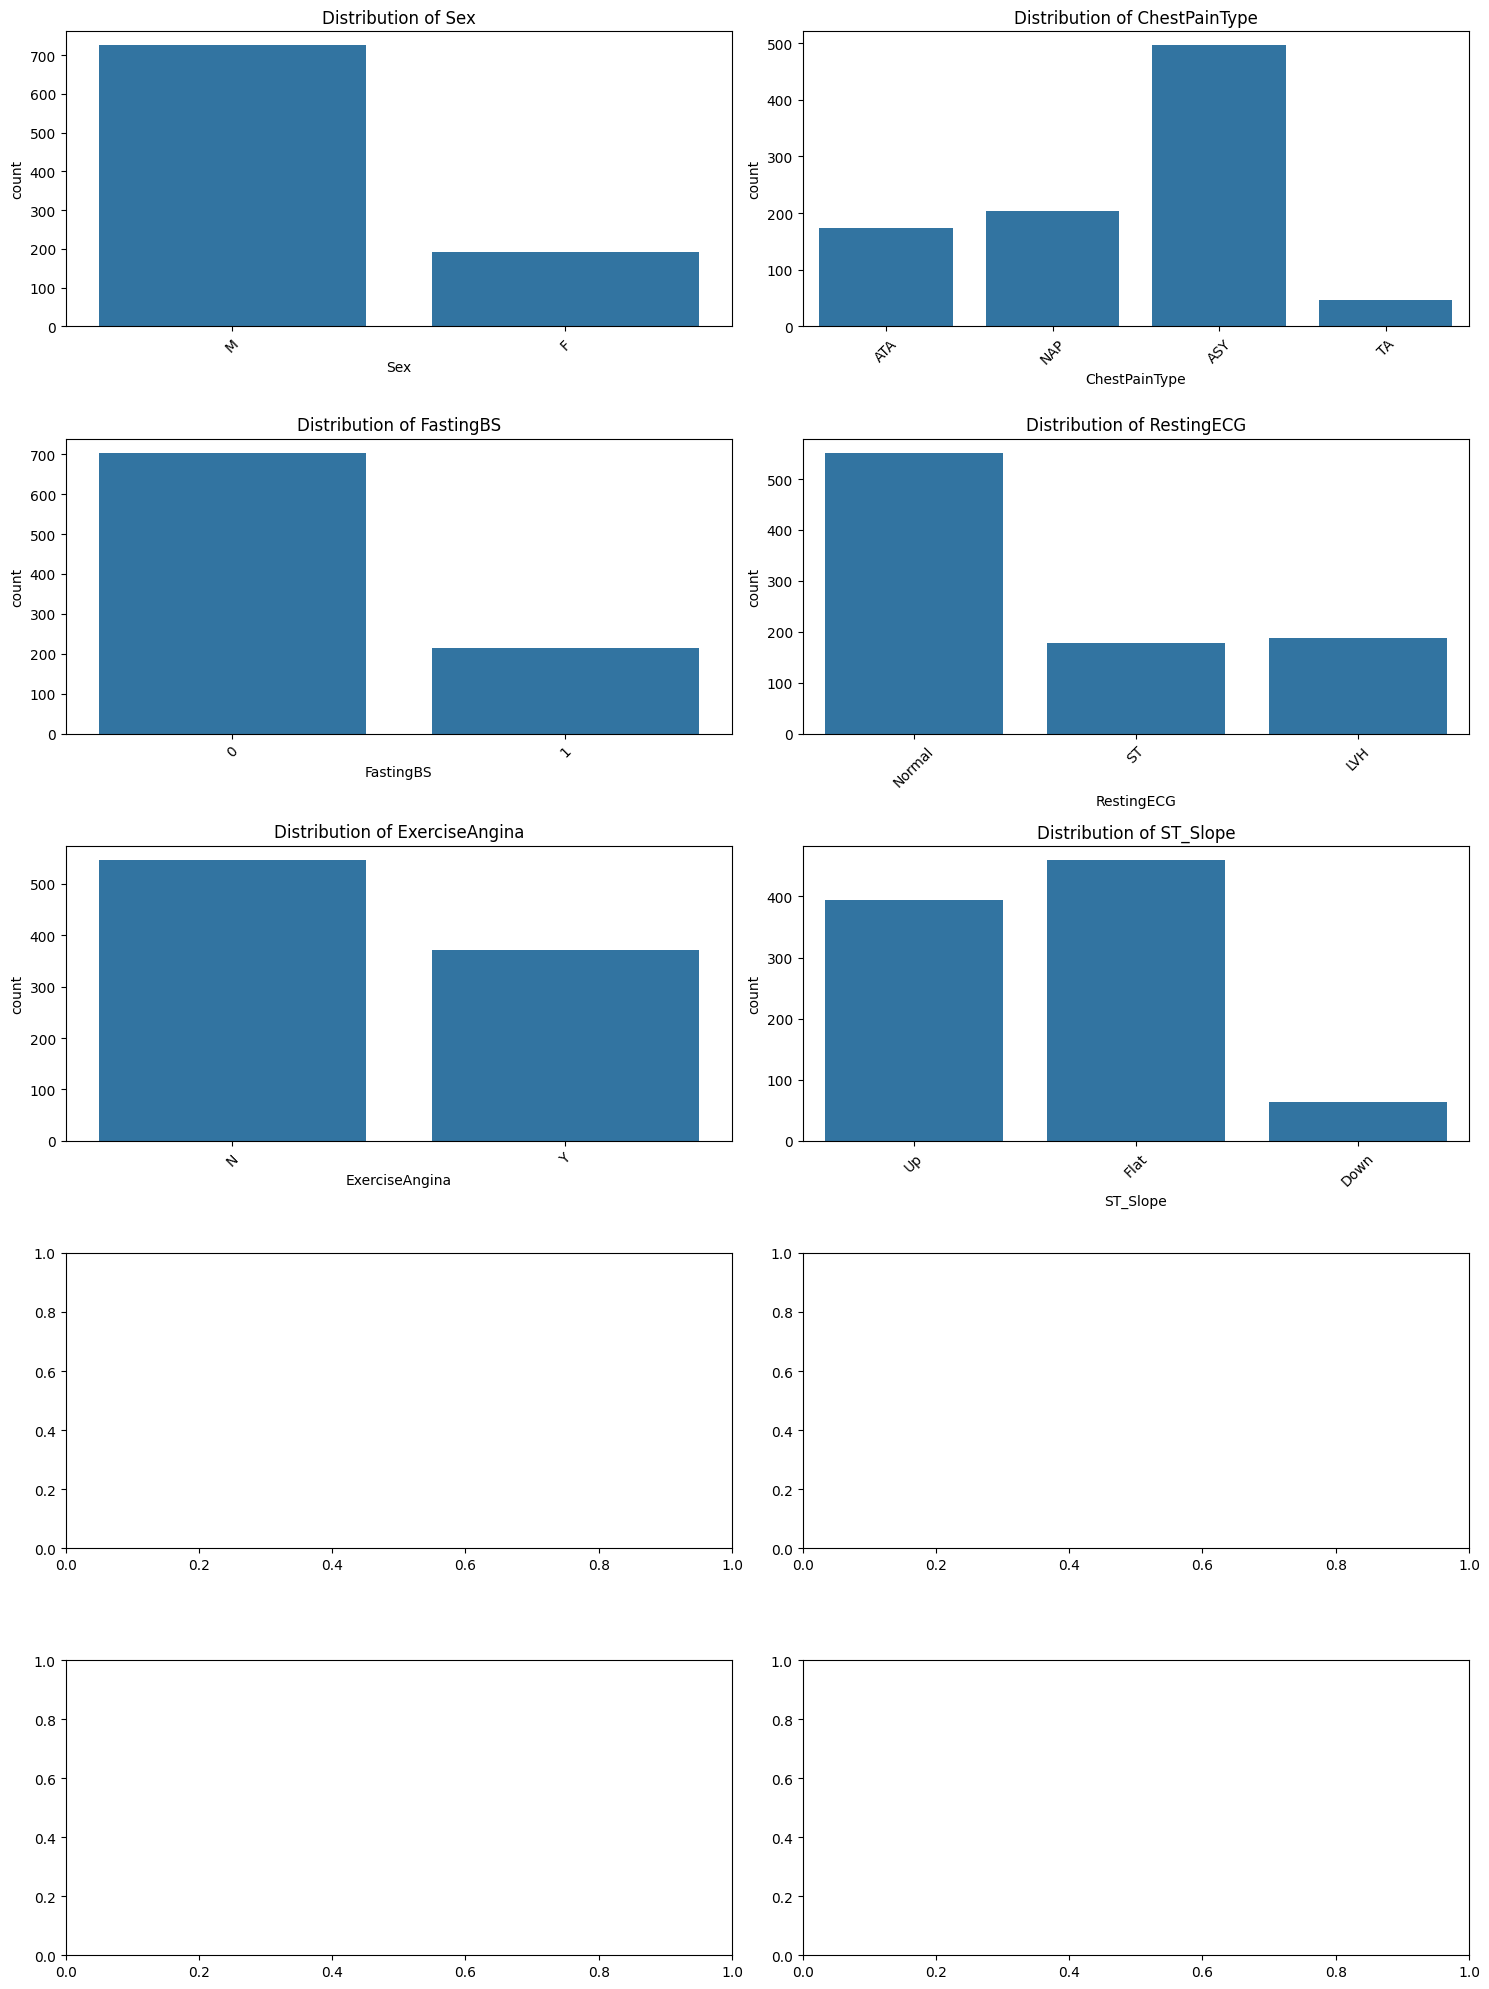

In [10]:
categorical_features = [  'Sex',
    'ChestPainType',
    'FastingBS',
    'RestingECG',
    'ExerciseAngina',
    'ST_Slope']

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 20))

for ax, feature in zip(axes.ravel(), categorical_features):
    sns.countplot(data=data, x=feature, ax=ax)
    ax.set_title(f"Distribution of {feature}")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()

### Data Exploration and Feature Analysis

The heart disease dataset comprises a mix of clinical and demographic variables. To prepare the data for classification, the features are categorized into two primary groups:

* **Categorical Features:** `Sex`, `ChestPainType`, `FastingBS`, `RestingECG`, `ExerciseAngina`, and `ST_Slope`.
* **Numerical Features:** `Age`, `RestingBP`, `Cholesterol`, `MaxHR`, and `Oldpeak`.

The following section investigates the integrity of the data by assessing the proportion of missing or placeholder values. Unlike the bank marketing dataset, this heart disease dataset is generally noted for its completeness; however, it is standard practice to verify the presence of null entries or "zero-values" that may serve as indicators of missing medical data (specifically in fields like `Cholesterol` or `RestingBP`).

For the purpose of this analysis, any "unknown" or logically inconsistent values will be quantified to determine if imputation or data cleaning is required before the model is trained and eventually exported for **Node.js** integration.


Let's also explore the relationship between some of the features and the target variable. For numerical features, we can use boxplots to visualize the distribution of the feature values for each class of the target variable.

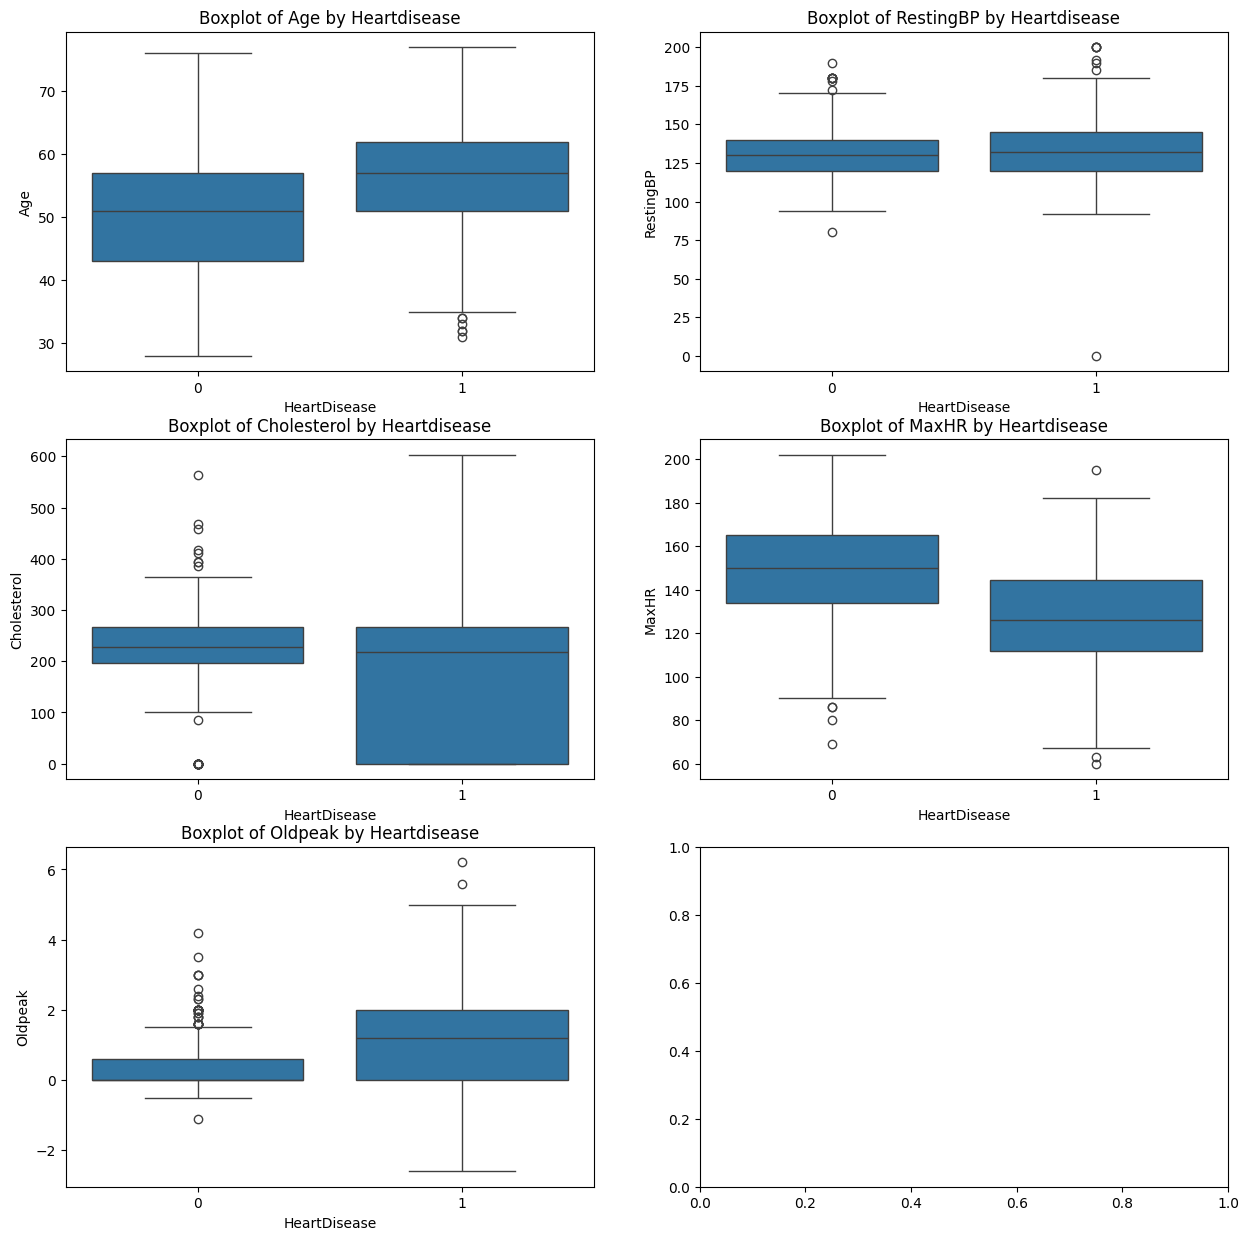

In [11]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))

for ax, feature in zip(axes.ravel(), numerical_features):
    sns.boxplot(data=data, x="HeartDisease", y=feature, ax=ax)
    ax.set_title(f"Boxplot of {feature} by Heartdisease")

We can also use countplots to visualize the relationship between categorical features and the target variable.

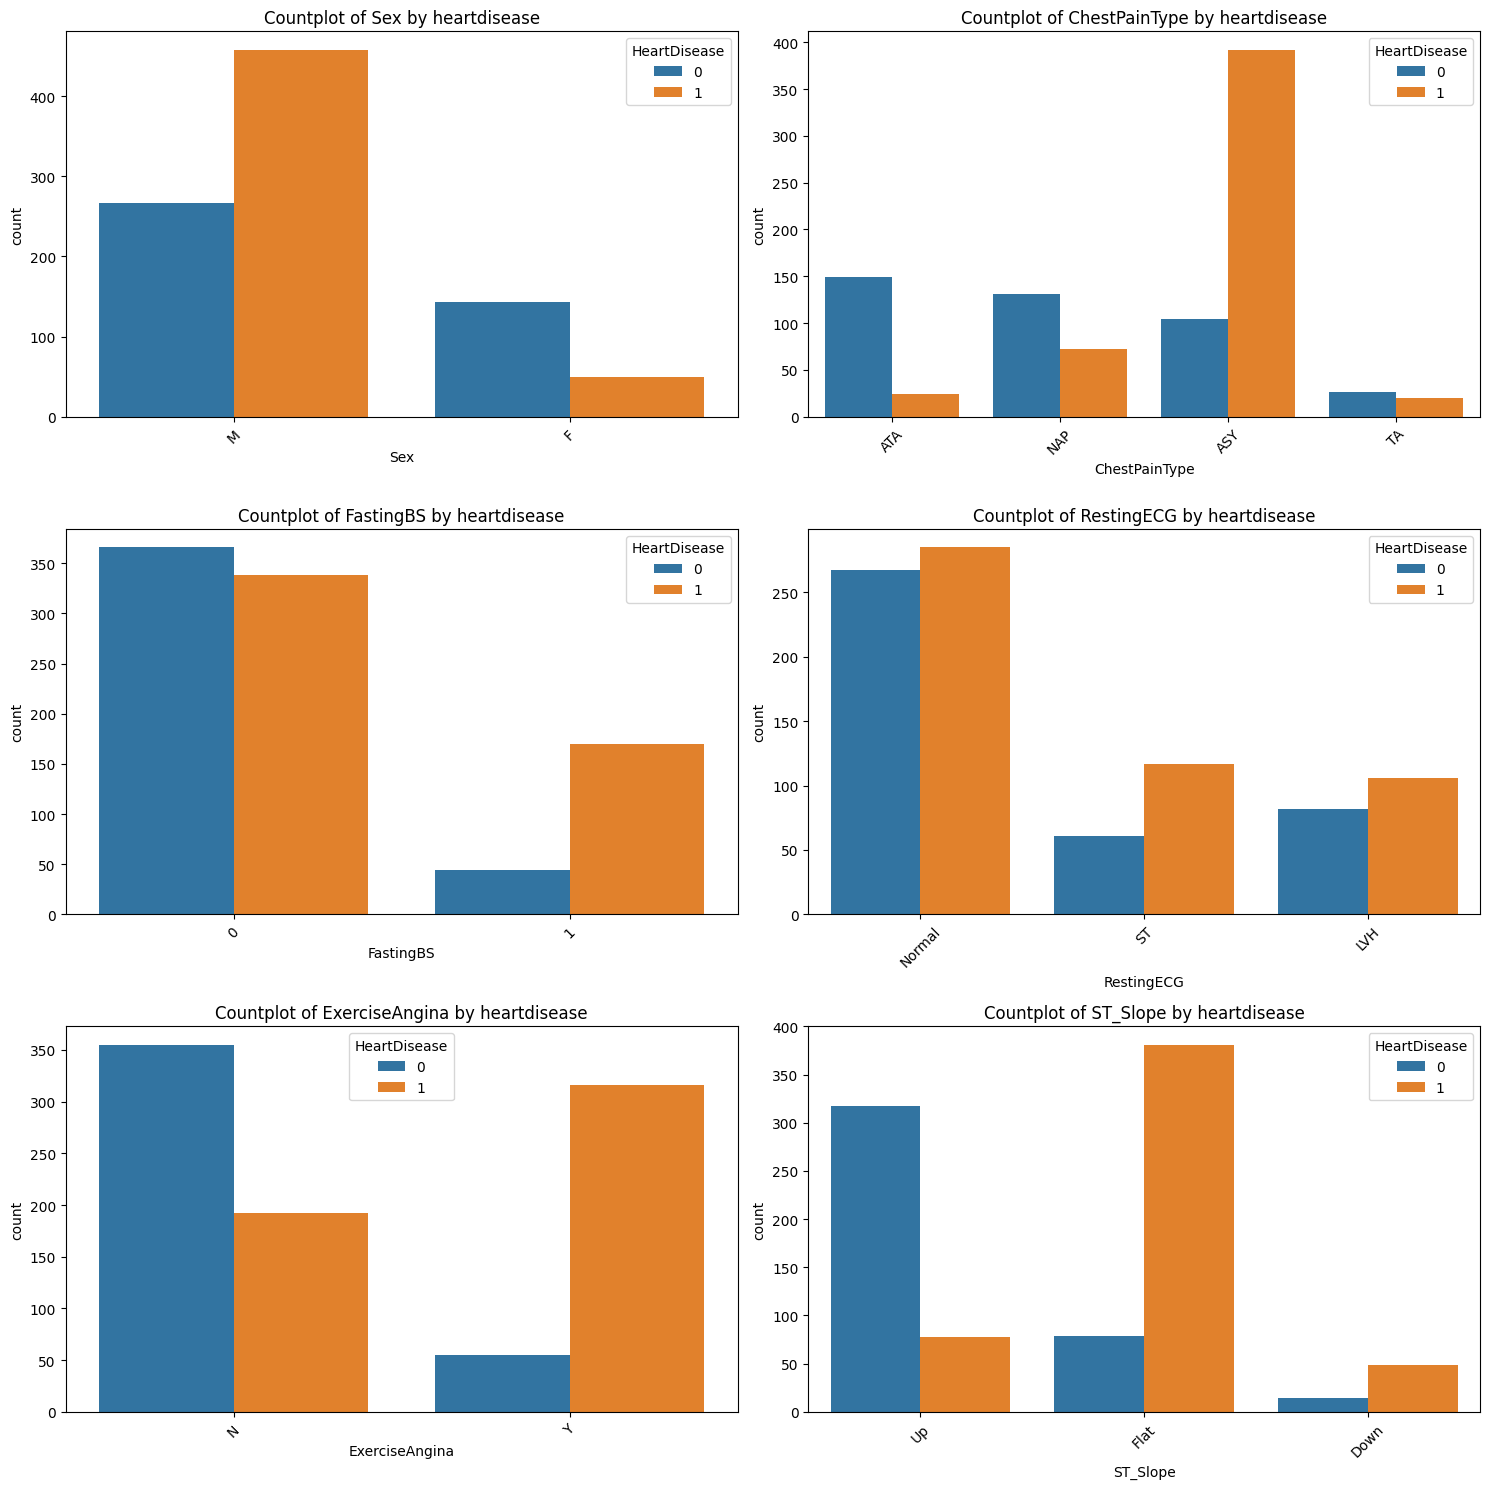

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))

for ax, feature in zip(axes.ravel(), categorical_features):
    sns.countplot(data=data, x=feature, hue="HeartDisease", ax=ax)
    ax.set_title(f"Countplot of {feature} by heartdisease")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Data Visualization and Exploratory Insights

Based on the generated boxplots and countplots for the Heart Disease dataset, several key insights can be derived regarding the relationship between the clinical features and the target variable (HeartDisease):

* **Clinical Indicators of Disease:** Patients diagnosed with heart disease (Class 1) tend to exhibit a higher **Oldpeak** (ST depression) and a significantly lower **MaxHR** (Maximum Heart Rate) compared to those without the condition.
* **Demographic and Categorical Trends:** The data suggests a higher prevalence of heart disease among **male** patients. Furthermore, certain categorical attributes, such as an **Asymptomatic (ASY)** chest pain type and a **Flat ST slope**, appear to be strong indicators of a positive diagnosis.
* **Influence of Exercise-Induced Symptoms:** There is a clear correlation between **ExerciseAngina** and heart disease; patients who experience angina during exercise are notably more likely to be classified as having heart disease.
* **Numerical Distributions and Outliers:** While **RestingBP** (Resting Blood Pressure) and **Age** show a slight upward trend in patients with heart disease, both features—particularly **Cholesterol**—contain several outliers (including zero-values for cholesterol) that may require preprocessing to avoid biasing the model.
* **ECG Results:** The **RestingECG** distribution shows that while a "Normal" result is common across both classes, "ST" and "LVH" (Left Ventricular Hypertrophy) results are more frequent in the heart disease group, though the difference is less pronounced than other categorical markers.


### Integration with Node.js

These insights are critical for feature selection. Once the most influential variables are identified and the model is trained, it will be converted (e.g., to a JSON or ONNX format) to enable real-time heart disease risk assessment within a **Node.js** application.


## Data preprocessing

Now that we have some understanding of the dataset, we can start with data preprocessing. We will create a pipeline to handle missing values, encode categorical features, and scale numerical features.

The first step is to separate the features and the target variable.

We will not drop any feature, there are no empty values.

In [13]:
data['FastingBS'] = data['FastingBS'].astype(str)
x = data[numerical_features + categorical_features]
y = data["HeartDisease"]

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer
from sklearn.impute import SimpleImputer

categorical_features = [
    'Sex',
    'ChestPainType',
    'FastingBS',
    'RestingECG',
    'ExerciseAngina',
    'ST_Slope'
]

preprocessing = ColumnTransformer(
    transformers=[
('cat', OneHotEncoder(handle_unknown="ignore"), categorical_features),

        ('num_power', make_pipeline(
            SimpleImputer(strategy='mean'),
            PowerTransformer(),
            StandardScaler()
        ), ['Oldpeak', 'Cholesterol']),

        ('num', make_pipeline(
            SimpleImputer(strategy='mean'),
            StandardScaler()
        ), ['Age', 'RestingBP', 'MaxHR']),
    ]
)

In [16]:
from sklearn.ensemble import RandomForestClassifier

model = Pipeline([
    ("preprocessing", preprocessing),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

### Model Pipeline Construction and Export

To ensure a robust and reproducible workflow, the model is built using a structured **Scikit-Learn Pipeline**. This approach encapsulates all preprocessing steps and the final classifier into a single object, preventing data leakage and simplifying the eventual deployment to a **Node.js** environment.

The architecture of the pipeline is as follows:

#### 1. Preprocessing Layer (`ColumnTransformer`)

The input data is split into three distinct processing paths based on the nature of the features:

* **Categorical Path (`cat`):** Processes features like `Sex` and `ChestPainType` using **OneHotEncoder** to convert labels into a machine-readable binary format.
* **Non-Linear Numerical Path (`num_power`):** For numerical variables with skewed distributions, a **SimpleImputer** handles missing values, followed by a **PowerTransformer** to stabilize variance and a **StandardScaler** to normalize the range.
* **Standard Numerical Path (`num`):** Remaining numerical features undergo basic **SimpleImputer** treatment and **StandardScaler** normalization.

#### 2. Classification Layer

* The final stage of the pipeline utilizes a **RandomForestClassifier**. This ensemble method is selected for its high predictive accuracy and ability to handle the complex, non-linear relationships identified during the exploratory data analysis.

In [17]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Sex', 'ChestPainType',
                                                   'FastingBS', 'RestingECG',
                                                   'ExerciseAngina',
                                                   'ST_Slope']),
                                                 ('num_power',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('powertransformer',
                                                                   PowerTransformer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['Oldpeak', 'Cholesterol']),
                                                 ('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'RestingBP',
                                                   'MaxHR'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [18]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.87      0.87        77
           1       0.91      0.91      0.91       107

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



### Model Conversion and Serialization for Node.js Integration

To bridge the gap between the Python training environment and a **Node.js** production backend, the trained pipeline must be converted into a cross-platform format. This implementation utilizes the **Open Neural Network Exchange (ONNX)** standard, which allows models to run efficiently across different runtimes without a Python dependency.

#### 1. Environment Setup

The process begins by installing `skl2onnx`, the specialized library for converting Scikit-Learn pipelines, and `onnxruntime`, which is used to verify the model's integrity.

#### 2. Defining Input Schema (`initial_types`)

Since ONNX requires strict typing, a schema is defined to map each feature from the `heartdisease.csv` dataset:

* **Numerical Inputs:** Features such as `Age`, `RestingBP`, and `Cholesterol` are explicitly defined as `FloatTensorType`.
* **Categorical Inputs:** String-based features like `Sex`, `ChestPainType`, and `ST_Slope` are defined as `StringTensorType`.
* **Dynamic Batching:** The `[None, 1]` notation ensures the model can process any number of rows (batch size) simultaneously during inference in Node.js.

#### 3. Conversion and Serialization

The `convert_sklearn` function translates the entire `RandomForestClassifier` pipeline—including the `OneHotEncoder` and `PowerTransformer` steps—into an optimized ONNX graph. The resulting binary is then serialized and saved as `heart_model2.onnx`.


### Deployment Readiness

Once the `.onnx` file is generated, it can be loaded into a **Node.js** application using the `onnxruntime-node` package. This allows for high-performance, real-time heart disease risk assessments directly within your web server or API.

Would you like me to provide the **Node.js** code snippet required to load this `.onnx` file and run a prediction with patient data?

In [19]:
pip install skl2onnx onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 49.3 MB/s eta 0:00:00


In [20]:
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType, StringTensorType

initial_types = [
    ('Age', FloatTensorType([None, 1])),
    ('RestingBP', FloatTensorType([None, 1])),
    ('Cholesterol', FloatTensorType([None, 1])),
    ('MaxHR', FloatTensorType([None, 1])),
    ('Oldpeak', FloatTensorType([None, 1])),

    ('Sex', StringTensorType([None, 1])),
    ('ChestPainType', StringTensorType([None, 1])),
    ('FastingBS', StringTensorType([None, 1])),
    ('RestingECG', StringTensorType([None, 1])),
    ('ExerciseAngina', StringTensorType([None, 1])),
    ('ST_Slope', StringTensorType([None, 1])),
]

onnx_model = convert_sklearn(
    model,
    initial_types=initial_types
)

with open("heart_model2.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())

print("Modelo exportado correctamente a heart_model.onnx")

Modelo exportado correctamente a heart_model.onnx


In [21]:
import onnxruntime as ort

sess = ort.InferenceSession("heart_model2.onnx")
print(sess.get_inputs())

[<onnxruntime.capi.onnxruntime_pybind11_state.NodeArg object at 0x7f7d55efdd70>, <onnxruntime.capi.onnxruntime_pybind11_state.NodeArg object at 0x7f7d55efc330>, <onnxruntime.capi.onnxruntime_pybind11_state.NodeArg object at 0x7f7d55eff730>, <onnxruntime.capi.onnxruntime_pybind11_state.NodeArg object at 0x7f7d55efc130>, <onnxruntime.capi.onnxruntime_pybind11_state.NodeArg object at 0x7f7d55d6d270>, <onnxruntime.capi.onnxruntime_pybind11_state.NodeArg object at 0x7f7d55ed4530>, <onnxruntime.capi.onnxruntime_pybind11_state.NodeArg object at 0x7f7d5601e9f0>, <onnxruntime.capi.onnxruntime_pybind11_state.NodeArg object at 0x7f7d5601ed70>, <onnxruntime.capi.onnxruntime_pybind11_state.NodeArg object at 0x7f7d5601f570>, <onnxruntime.capi.onnxruntime_pybind11_state.NodeArg object at 0x7f7d5601deb0>, <onnxruntime.capi.onnxruntime_pybind11_state.NodeArg object at 0x7f7d5601d7f0>]


### Model Evaluation and Performance Metrics

Before finalizing the export to **Node.js**, it is essential to rigorously evaluate the model's predictive capabilities. Because heart disease diagnosis carries significant clinical weight, we must look beyond simple accuracy and examine how the model handles false positives and, more critically, false negatives.

To achieve this, the following evaluations are performed:

* **Confusion Matrix:** A visualization of the model’s performance, showing the distribution of true positives, true negatives, false positives (Type I errors), and false negatives (Type II errors).
* **Correlation Matrix:** A heatmap used to identify the statistical relationship between clinical features and the target variable, ensuring that the model is relying on medically relevant patterns.
* **Classification Report:** A detailed summary providing **Precision**, **Recall**, and the **F1-Score** for both healthy and diseased patient classes.
* **Feature Importance:** An analysis of the Random Forest's internal decision-making to identify which clinical markers (e.g., `ST_Slope` or `MaxHR`) were most influential in the final prediction.

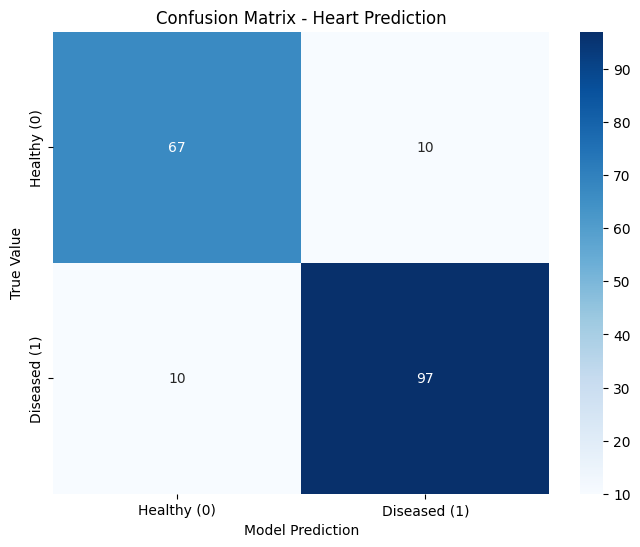

--- Classification Report ---
              precision    recall  f1-score   support

 Healthy (0)       0.87      0.87      0.87        77
Diseased (1)       0.91      0.91      0.91       107

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



<Figure size 800x600 with 0 Axes>

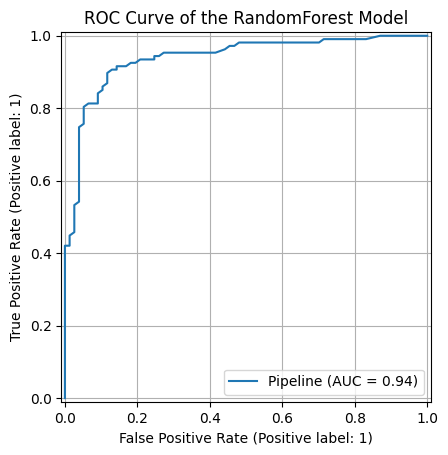

In [28]:
from sklearn.metrics import confusion_matrix, classification_report, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Make predictions with the test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# 2. Generate the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy (0)', 'Diseased (1)'],
            yticklabels=['Healthy (0)', 'Diseased (1)'])
plt.title('Confusion Matrix - Heart Prediction')
plt.xlabel('Model Prediction')
plt.ylabel('True Value')
plt.show()

# 3. Display the Classification Report
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Healthy (0)', 'Diseased (1)']))

# 4. Visualize the ROC Curve
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title('ROC Curve of the RandomForest Model')
plt.grid(True)
plt.show()